# rapids-singlecell GPU Harmonized Benchmark

GPU pipeline mirroring the Scanpy CPU reference.

**Key choices:**
- Same canonical input as CPU
- HVG: seurat_v3 on raw counts
- PCA: rsc sparse zero-centered PCA
- KNN: **exact** brute-force (cuML)
- Leiden: cuGraph (n_iterations = default unless configured)
- DE: rsc GPU Wilcoxon

Change `DATASET` below and re-run.

In [1]:
# === CHANGE THIS TO SWITCH DATASETS ===
DATASET = "pbmc3k"   # or "lung65k"
RMM_MODE = "pool"    # "pool" for PBMC3k, "managed" for Lung65k on 12GB GPU

CONFIG_PATH = "benchmark_config.json"

In [2]:
import json
import os
import inspect
import pandas as pd
import scanpy as sc
import rapids_singlecell as rsc

print(f"Scanpy: {sc.__version__}")
print(f"rapids-singlecell: {rsc.__version__}")

try:
    import cupy as cp
    print(f"CuPy: {cp.__version__}")
except ImportError:
    print("CuPy: NOT AVAILABLE")

with open(CONFIG_PATH) as f:
    config = json.load(f)
gcfg = config["global"]
dcfg = config["datasets"][DATASET]
prefix = dcfg["pipeline_prefix"]

os.makedirs("write", exist_ok=True)
print(f"Dataset: {dcfg['name']}")

Scanpy: 1.12
rapids-singlecell: 0.14.1
CuPy: 14.0.1
Dataset: PBMC3k


/tmp/ipykernel_11718/2625300413.py:8: FutureWarning: `__version__` is deprecated, use `importlib.metadata.version('scanpy')` instead
  print(f"Scanpy: {sc.__version__}")


In [3]:
# Optional RMM initialization
if RMM_MODE != "none":
    import cupy as cp
    import rmm
    from rmm.allocators.cupy import rmm_cupy_allocator
    rmm.reinitialize(
        pool_allocator=True,
        managed_memory=(RMM_MODE == "managed"),
    )
    cp.cuda.set_allocator(rmm_cupy_allocator)
    print(f"RMM initialized: {RMM_MODE}")
else:
    print("RMM: none")

RMM initialized: pool


In [4]:
%%time
# Load canonical filtered input
adata = sc.read_h5ad(dcfg["canonical_h5ad"])
assert "counts" in adata.layers, "Missing counts layer"
print(f"Loaded: {adata.n_obs:,} cells × {adata.n_vars:,} genes")

# Move to GPU
rsc.get.anndata_to_GPU(adata)
print("Moved to GPU")

Loaded: 2,638 cells × 13,714 genes
Moved to GPU
CPU times: user 123 ms, sys: 19.7 ms, total: 143 ms
Wall time: 141 ms


In [5]:
%%time
# Normalize + log1p
rsc.pp.normalize_total(adata, target_sum=gcfg["target_sum"])
rsc.pp.log1p(adata)
print("Normalized")

Normalized
CPU times: user 170 ms, sys: 5.01 ms, total: 175 ms
Wall time: 181 ms


In [6]:
%%time
# HVG on raw counts — must be on GPU
import cupyx.scipy.sparse as cusp
import cupy as cp

# Move counts layer to GPU manually
if "counts" in adata.layers:
    counts_cpu = adata.layers["counts"]
    if not isinstance(counts_cpu, cusp.spmatrix):
        from scipy import sparse as sp_sparse
        if sp_sparse.issparse(counts_cpu):
            adata.layers["counts"] = cusp.csr_matrix(counts_cpu)
        else:
            adata.layers["counts"] = cp.array(counts_cpu)

rsc.pp.highly_variable_genes(
    adata,
    layer="counts",
    n_top_genes=dcfg["n_top_genes"],
    flavor="seurat_v3",
)
print(f"HVGs: {adata.var.highly_variable.sum()}")

HVGs: 2000
CPU times: user 2.05 s, sys: 83.7 ms, total: 2.14 s
Wall time: 2.17 s


In [7]:
%%time
# PCA
rsc.pp.pca(
    adata,
    n_comps=gcfg["pca_n_comps"],
    mask_var="highly_variable",
)
print("PCA done")

PCA done
CPU times: user 912 ms, sys: 53.6 ms, total: 966 ms
Wall time: 959 ms


In [8]:
%%time
# Exact brute-force KNN on GPU
rsc.pp.neighbors(
    adata,
    n_neighbors=dcfg["n_neighbors"],
    n_pcs=dcfg["neighbors_n_pcs"],
    use_rep="X_pca",
    algorithm="brute",
    metric=gcfg["neighbor_metric"],
    method=gcfg["neighbor_method"],
    random_state=gcfg["random_state"],
)
print("Neighbors computed (exact brute-force GPU)")

Neighbors computed (exact brute-force GPU)
CPU times: user 484 ms, sys: 26.2 ms, total: 510 ms
Wall time: 506 ms


In [9]:
%%time
# Leiden clustering
leiden_kwargs = {
    "resolution": dcfg["leiden_resolution"],
    "random_state": gcfg["random_state"],
    "key_added": "leiden",
}
if gcfg.get("rsc_leiden_n_iterations") is not None:
    leiden_kwargs["n_iterations"] = gcfg["rsc_leiden_n_iterations"]
rsc.tl.leiden(adata, **leiden_kwargs)
print(f"Leiden clusters: {adata.obs.leiden.nunique()}")

Leiden clusters: 9
CPU times: user 366 ms, sys: 129 ms, total: 495 ms
Wall time: 496 ms


In [10]:
%%time
# UMAP
rsc.tl.umap(
    adata,
    min_dist=gcfg["umap_min_dist"],
    spread=gcfg["umap_spread"],
    init_pos="spectral",
    random_state=gcfg["random_state"],
)
print("UMAP done")

UMAP done
CPU times: user 67.7 ms, sys: 49.4 ms, total: 117 ms
Wall time: 116 ms


In [11]:
%%time
# DE — GPU Wilcoxon
rank_sig = inspect.signature(rsc.tl.rank_genes_groups)
rank_kwargs = {
    "groupby": "leiden",
    "method": gcfg["de_method"],
    "corr_method": gcfg["de_corr_method"],
    "use_raw": False,
    "pts": True,
}
# Be defensive: only pass supported kwargs
for key, val in {"pre_load": True, "tie_correct": False, "use_continuity": False}.items():
    if key in rank_sig.parameters:
        rank_kwargs[key] = val
rsc.tl.rank_genes_groups(adata, **rank_kwargs)

# Move to CPU for marker extraction
rsc.get.anndata_to_CPU(adata)

markers = sc.get.rank_genes_groups_df(adata, group=None)
markers_filtered = markers[
    (markers["pvals_adj"] < 0.05) & (markers["logfoldchanges"] > 0.1)
].copy()
print(f"DE genes: {len(markers)} total, {len(markers_filtered)} filtered")

/home/seyun/anaconda3/envs/rsc_0141/lib/python3.13/site-packages/rapids_singlecell/tools/_rank_genes_groups/__init__.py:201: RuntimeWarning: Group 2 has size 12 (rest 2626); normal approximation of the Wilcoxon statistic may be inaccurate.
  test_obj.compute_statistics(


DE genes: 123426 total, 3036 filtered
CPU times: user 1.65 s, sys: 70.8 ms, total: 1.73 s
Wall time: 1.71 s


In [12]:
# Save all outputs
out_prefix = f"write/{prefix}_rsc_gpu_0141_harmonized"

adata.write_h5ad(f"{out_prefix}.h5ad", compression="gzip")

pd.DataFrame({
    "barcode": adata.obs_names.astype(str),
    "leiden": adata.obs["leiden"].astype(str).values,
}).to_csv(f"{out_prefix}_clusters.csv", index=False)

markers.to_csv(f"{out_prefix}_markers.csv", index=False)
markers_filtered.to_csv(f"{out_prefix}_markers_filtered.csv", index=False)

pd.DataFrame(
    adata.obsm["X_umap"],
    index=adata.obs_names.astype(str),
    columns=["UMAP_1", "UMAP_2"],
).reset_index(names="barcode").to_csv(f"{out_prefix}_umap.csv", index=False)

hvg_df = adata.var.loc[adata.var["highly_variable"].astype(bool), []].copy()
hvg_df.index.name = "gene"
hvg_df.reset_index().to_csv(f"{out_prefix}_hvg.csv", index=False)

print(f"All outputs saved with prefix: {out_prefix}")

All outputs saved with prefix: write/pbmc3k_rsc_gpu_0141_harmonized


In [13]:
# Spec JSON
spec = {
    "pipeline": "rsc_gpu_harmonized",
    "dataset": dcfg["name"],
    "rapids_singlecell_version": rsc.__version__,
    "input": dcfg["canonical_h5ad"],
    "parameters": {
        "target_sum": gcfg["target_sum"],
        "hvg_flavor": "seurat_v3", "hvg_layer": "counts",
        "n_top_genes": dcfg["n_top_genes"],
        "pca_n_comps": gcfg["pca_n_comps"],
        "n_neighbors": dcfg["n_neighbors"],
        "neighbors_n_pcs": dcfg["neighbors_n_pcs"],
        "neighbor_backend": "rapids_singlecell.pp.neighbors(algorithm=brute)",
        "leiden_n_iterations": gcfg.get("rsc_leiden_n_iterations"),
        "leiden_resolution": dcfg["leiden_resolution"],
        "random_state": gcfg["random_state"],
        "de_method": gcfg["de_method"],
    },
    "results": {
        "n_cells": int(adata.n_obs),
        "n_genes": int(adata.n_vars),
        "n_hvg": int(adata.var["highly_variable"].sum()),
        "n_clusters": int(adata.obs["leiden"].nunique()),
        "n_markers": len(markers),
        "n_markers_filtered": len(markers_filtered),
    },
}
with open(f"{out_prefix}_spec.json", "w") as f:
    json.dump(spec, f, indent=2)
print(json.dumps(spec["results"], indent=2))

{
  "n_cells": 2638,
  "n_genes": 13714,
  "n_hvg": 2000,
  "n_clusters": 9,
  "n_markers": 123426,
  "n_markers_filtered": 3036
}


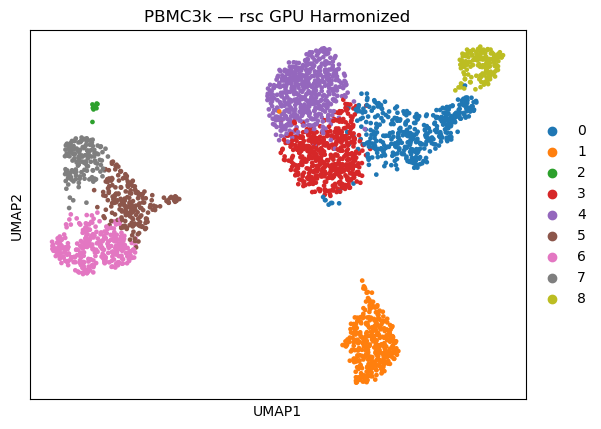

In [14]:
# Quick UMAP plot
sc.pl.umap(adata, color="leiden", title=f"{dcfg['name']} — rsc GPU Harmonized")